# Specialist Decoder Sweep: p_L vs p_physical

Evaluate **SimpleNN**, **GraphSAGE**, and **MWPM** specialist decoders across:
- Distances: d ∈ {3, 5, 7, 9, 11, 13}
- Physical error rates: p ∈ {0.001, 0.002, 0.003, 0.004, 0.005, 0.006, 0.007, 0.008}

All three decoders see **identical shots** at each (d, p) pair for a fair comparison.

**Key output:** log-log plot of p_L vs p with one line per distance — lines should fan out (lower p_L for higher d at low p), demonstrating real decoding.

In [29]:
import sys
import os
import hashlib
import numpy as np
import pandas as pd
import torch
import stim
import pymatching
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
from pathlib import Path
from datetime import datetime
from tqdm.auto import tqdm
from torch_geometric.loader import DataLoader

# Path setup
try:
    import google.colab
    from google.colab import drive
    drive.mount('/content/drive')
    BASE_PATH = Path('/content/drive/MyDrive/Research/QEC/quantum-error-correction/quantum-error-correction/code')
except ImportError:
    BASE_PATH = Path('../../')  # code/results/nn_vs_gnn_comparison -> code/

sys.path.insert(0, str(BASE_PATH))
from models import SurfaceCodeSampler, SparseGraph, GraphSAGE
from benchmark_models import SimpleNN, SimpleNNModel

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")
print(f"Base path: {BASE_PATH.resolve()}")

Device: cuda
Base path: G:\My Drive\Research\QEC\quantum-error-correction\quantum-error-correction\code


In [30]:
# ── Configuration ──

DISTANCES = [3, 5, 7, 9, 11, 13]
P_VALUES = [0.001, 0.002, 0.003, 0.004, 0.005, 0.006, 0.007, 0.008]
NUM_SAMPLES = 20_000
BATCH_SIZE = 256

# Output paths
OUTPUT_DIR = Path(".")  # same dir as this notebook
CSV_PATH = OUTPUT_DIR / "specialist_sweep_results.csv"
FIG_DIR = OUTPUT_DIR

# SimpleNN specialist model paths (custom save format)
NN_MODEL_DIR = BASE_PATH / "nn" / "training" / "models" / "revised_training"
NN_PATHS = {
    3:  NN_MODEL_DIR / "d3_specialist.pt",
    5:  NN_MODEL_DIR / "d5_specialist.pt",
    7:  NN_MODEL_DIR / "d7_specialist.pt",
    9:  NN_MODEL_DIR / "d9_specialist.pt",
    11: NN_MODEL_DIR / "fix2" / "d11_specialist.pt",
    13: NN_MODEL_DIR / "d13_specialist.pt",
}

# GraphSAGE specialist model paths
GNN_MODEL_DIR = BASE_PATH / "gSAGE" / "distances" / "models" / "revised_training"
GNN_PATHS = {d: GNN_MODEL_DIR / f"d{d}.pt" for d in DISTANCES}

# Verify all model files exist
for d in DISTANCES:
    assert NN_PATHS[d].exists(), f"Missing SimpleNN d={d}: {NN_PATHS[d]}"
    assert GNN_PATHS[d].exists(), f"Missing GraphSAGE d={d}: {GNN_PATHS[d]}"
print(f"All {len(DISTANCES)} specialist models verified for both decoders.")

All 6 specialist models verified for both decoders.


In [31]:
# ── Model Loaders ──
import io

def _torch_load_safe(path, device):
    """Load a torch checkpoint by reading bytes first (workaround for Google Drive)."""
    with open(path, 'rb') as f:
        buf = io.BytesIO(f.read())
    return torch.load(buf, map_location=device, weights_only=False)


def load_simplenn(d: int) -> SimpleNNModel:
    """Load a SimpleNN specialist (custom save format: hyperparams + state_dict)."""
    path = NN_PATHS[d].resolve()
    save_dict = _torch_load_safe(path, DEVICE)
    hp = save_dict['hyperparams']
    model = SimpleNNModel(
        in_channels=save_dict['num_detectors'],
        hidden_dims=hp['hidden_dims'],
        dropout=hp['dropout']
    ).to(DEVICE)
    model.load_state_dict(save_dict['state_dict'])
    model.eval()
    print(f"  SimpleNN d={d}: {save_dict['num_detectors']} detectors, dims={hp['hidden_dims']}")
    return model


def load_graphsage(d: int):
    """Load a GraphSAGE specialist directly from checkpoint (bypasses wrapper)."""
    path = GNN_PATHS[d].resolve()
    save_dict = _torch_load_safe(path, DEVICE)
    config = save_dict['config']
    from models import GraphSAGEModel
    model = GraphSAGEModel(
        in_channels=config['in_channels'],
        hidden_dim=config['hidden_dim'],
        num_layers=config['num_layers'],
        dropout=config.get('dropout', 0.0),
        aggr=config.get('aggr', 'mean')
    ).to(DEVICE)
    model.load_state_dict(save_dict['state_dict'])
    model.eval()
    print(f"  GraphSAGE d={d}: config={config}")
    return model

In [32]:
# ── Evaluation Helpers ──

def eval_simplenn(model: SimpleNNModel, det_pm1: torch.Tensor, labels: torch.Tensor,
                  batch_size: int = 256) -> tuple:
    """Evaluate SimpleNN on shared shots. Returns (p_L, num_errors)."""
    model.eval()
    correct = 0
    n = det_pm1.shape[0]
    with torch.no_grad():
        for start in range(0, n, batch_size):
            end = min(start + batch_size, n)
            pred = model(det_pm1[start:end])  # [batch, 1]
            y = labels[start:end].unsqueeze(1)
            correct += ((pred > 0.5).float() == y).sum().item()
    num_errors = n - int(correct)
    return num_errors / n, num_errors


def eval_graphsage(model, graphs: list, batch_size: int = 256) -> tuple:
    """Evaluate GraphSAGEModel on PyG graphs. Returns (p_L, num_errors)."""
    model.eval()
    loader = DataLoader(graphs, batch_size=batch_size, shuffle=False)
    correct = 0
    total = 0
    with torch.no_grad():
        for batch in loader:
            batch = batch.to(DEVICE)
            pred = model(batch)  # raw sigmoid output
            y = batch.y.float().view(-1, 1)
            correct += ((pred > 0.5).float() == y).sum().item()
            total += y.size(0)
    num_errors = total - int(correct)
    return num_errors / total, num_errors


def mwpm_on_shots(circuit: stim.Circuit, detection_events: np.ndarray,
                  observable_flips: np.ndarray) -> tuple:
    """Decode shared shots with MWPM (pymatching). Returns (p_L, num_errors)."""
    dem = circuit.detector_error_model(decompose_errors=True)
    matcher = pymatching.Matching.from_detector_error_model(dem)
    preds = matcher.decode_batch(detection_events)
    mistakes = int(np.any(preds != observable_flips, axis=1).sum())
    return mistakes / len(detection_events), mistakes

In [33]:
# ── Resume Support ──

def load_existing_rows(csv_path: Path) -> list:
    """Load previously completed results for resume support."""
    if csv_path.exists():
        df = pd.read_csv(csv_path)
        rows = df.to_dict('records')
        print(f"Loaded {len(rows)} existing results from {csv_path}")
        return rows
    return []

def get_completed(rows: list) -> set:
    """Get set of (decoder, d, p) already completed."""
    return {(r['decoder'], r['d'], r['p']) for r in rows}

def all_done(rows: list, d: int, p: float) -> bool:
    """Check if all 3 decoders done for this (d, p)."""
    completed = get_completed(rows)
    return all((dec, d, p) in completed for dec in ["SimpleNN", "GraphSAGE", "MWPM"])

def save_csv(rows: list, csv_path: Path):
    """Save current results to CSV."""
    df = pd.DataFrame(rows)
    df.to_csv(csv_path, index=False)

rows = load_existing_rows(CSV_PATH)
completed = get_completed(rows)
remaining = sum(1 for d in DISTANCES for p in P_VALUES if not all_done(rows, d, p))
print(f"Completed (d,p) pairs: {len(DISTANCES)*len(P_VALUES) - remaining}/{len(DISTANCES)*len(P_VALUES)}")

Loaded 144 existing results from specialist_sweep_results.csv
Completed (d,p) pairs: 48/48


In [34]:
# ── Main Sweep ──

sampler = SurfaceCodeSampler(device=DEVICE)
sg = SparseGraph(device=DEVICE)

total_pairs = len(DISTANCES) * len(P_VALUES)
pair_idx = 0

for d in DISTANCES:
    print(f"\n{'='*70}")
    print(f"Distance d={d}")
    print(f"{'='*70}")

    nn_model = load_simplenn(d)
    gnn_model = load_graphsage(d)

    for p in P_VALUES:
        pair_idx += 1

        if all_done(rows, d, p):
            print(f"  [{pair_idx}/{total_pairs}] d={d}, p={p} — already done, skipping")
            continue

        print(f"  [{pair_idx}/{total_pairs}] d={d}, p={p} — generating {NUM_SAMPLES} shared shots...")

        # Generate shared shots via stim
        circuit = sampler._get_circuit(d, p)
        det_sampler = circuit.compile_detector_sampler()
        det_bool, obs_bool = det_sampler.sample(NUM_SAMPLES, separate_observables=True)

        # Log a hash to verify identical-shot guarantee
        shot_hash = hashlib.md5(det_bool.tobytes()).hexdigest()[:8]
        print(f"    Shot hash: {shot_hash}")

        # Convert to NN/GNN format: {-1, +1} floats
        det_pm1 = torch.from_numpy(det_bool.astype(np.float32) * 2 - 1).to(DEVICE)
        labels = torch.from_numpy(obs_bool.astype(np.float32).flatten()).to(DEVICE)

        timestamp = datetime.now().isoformat()
        completed = get_completed(rows)

        # (a) SimpleNN
        if ("SimpleNN", d, p) not in completed:
            pL_nn, nerr_nn = eval_simplenn(nn_model, det_pm1, labels, BATCH_SIZE)
            stderr_nn = np.sqrt(pL_nn * (1 - pL_nn) / NUM_SAMPLES)
            rows.append(dict(decoder="SimpleNN", d=d, p=p, num_samples=NUM_SAMPLES,
                             num_errors=nerr_nn, p_L=pL_nn, p_L_stderr=stderr_nn,
                             shot_hash=shot_hash, timestamp=timestamp))
            print(f"    SimpleNN:  p_L={pL_nn:.5f} ± {stderr_nn:.5f} ({nerr_nn}/{NUM_SAMPLES} errors)")

        # (b) GraphSAGE
        if ("GraphSAGE", d, p) not in completed:
            print(f"    Building {NUM_SAMPLES} PyG graphs...")
            graphs = [sg.to_pyg(det_pm1[i], labels[i]) for i in tqdm(range(NUM_SAMPLES), desc="to_pyg", leave=False)]
            pL_gnn, nerr_gnn = eval_graphsage(gnn_model, graphs, BATCH_SIZE)
            stderr_gnn = np.sqrt(pL_gnn * (1 - pL_gnn) / NUM_SAMPLES)
            rows.append(dict(decoder="GraphSAGE", d=d, p=p, num_samples=NUM_SAMPLES,
                             num_errors=nerr_gnn, p_L=pL_gnn, p_L_stderr=stderr_gnn,
                             shot_hash=shot_hash, timestamp=timestamp))
            print(f"    GraphSAGE: p_L={pL_gnn:.5f} ± {stderr_gnn:.5f} ({nerr_gnn}/{NUM_SAMPLES} errors)")
            del graphs

        # (c) MWPM on same raw shots
        if ("MWPM", d, p) not in completed:
            pL_mwpm, nerr_mwpm = mwpm_on_shots(circuit, det_bool, obs_bool)
            stderr_mwpm = np.sqrt(pL_mwpm * (1 - pL_mwpm) / NUM_SAMPLES)
            rows.append(dict(decoder="MWPM", d=d, p=p, num_samples=NUM_SAMPLES,
                             num_errors=nerr_mwpm, p_L=pL_mwpm, p_L_stderr=stderr_mwpm,
                             shot_hash=shot_hash, timestamp=timestamp))
            print(f"    MWPM:      p_L={pL_mwpm:.5f} ± {stderr_mwpm:.5f} ({nerr_mwpm}/{NUM_SAMPLES} errors)")

        # Checkpoint after every (d, p)
        save_csv(rows, CSV_PATH)

    # Free GPU memory between distances
    del nn_model, gnn_model
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

print(f"\n{'='*70}")
print(f"SWEEP COMPLETE — {len(rows)} total results saved to {CSV_PATH}")
print(f"{'='*70}")

SurfaceCodeSampler initialized:
  Default error rate: 0.01
  Device: cuda
  Mode: Dynamic (supports any code distance)
SparseGraph initialized:
  K neighbors: 6
  Device: cuda
  Mode: Dynamic (supports any code distance)

Distance d=3
  SimpleNN d=3: 24 detectors, dims=(512, 1024, 2048)
  GraphSAGE d=3: config={'in_channels': 5, 'hidden_dim': 256, 'num_layers': 5, 'dropout': 0.1, 'aggr': 'max', 'seed': 42}
  [1/48] d=3, p=0.001 — already done, skipping
  [2/48] d=3, p=0.002 — already done, skipping
  [3/48] d=3, p=0.003 — already done, skipping
  [4/48] d=3, p=0.004 — already done, skipping
  [5/48] d=3, p=0.005 — already done, skipping
  [6/48] d=3, p=0.006 — already done, skipping
  [7/48] d=3, p=0.007 — already done, skipping
  [8/48] d=3, p=0.008 — already done, skipping

Distance d=5
  SimpleNN d=5: 120 detectors, dims=(512, 1024, 2048)
  GraphSAGE d=5: config={'in_channels': 5, 'hidden_dim': 256, 'num_layers': 5, 'dropout': 0.1, 'aggr': 'max', 'seed': 42}
  [9/48] d=5, p=0.001 — 

Saved: specialist_sweep_3panel.png


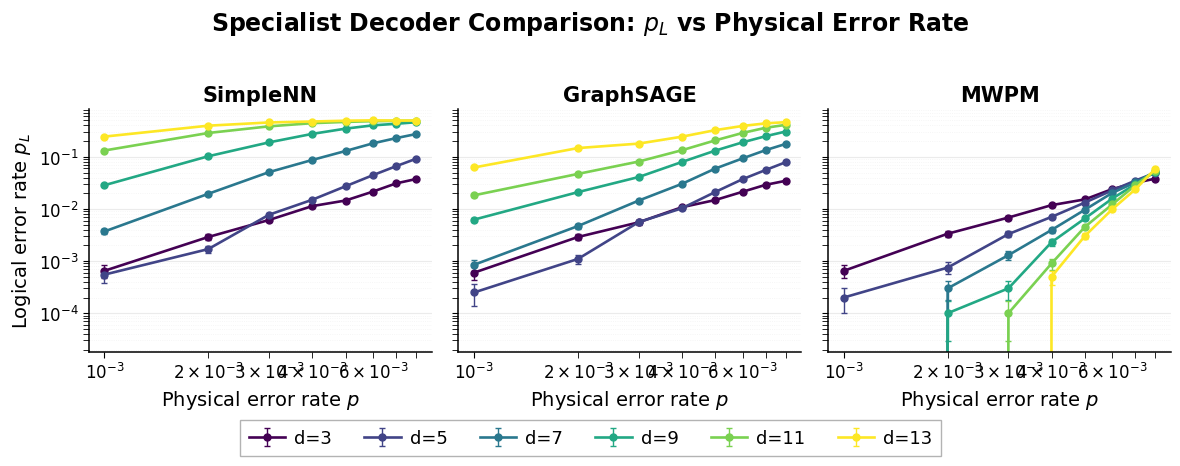

In [35]:
# ── Plot 1: 3-Panel Subplots — quad-chart-friendly condensed version ──

df = pd.read_csv(CSV_PATH)

DIST_COLORS = {d: plt.cm.viridis(i / (len(DISTANCES) - 1)) for i, d in enumerate(DISTANCES)}
DECODERS = ["SimpleNN", "GraphSAGE", "MWPM"]

# Bumped font sizes across the board so the figure stays legible when shrunk
# to a quad-chart cell. Legend consolidated into a single horizontal strip
# at the bottom (ncol=6) — frees up panel space AND lets the distance labels
# be big without competing with panel content.
plt.rcParams.update({
    "font.family": "DejaVu Sans",
    "font.size": 13,
    "axes.titlesize": 15,
    "axes.labelsize": 14,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "legend.fontsize": 13,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.linewidth": 1.1,
})

fig, axes = plt.subplots(1, 3, figsize=(12, 4.3), sharey=True)

line_handles = []
for i, (ax, decoder) in enumerate(zip(axes, DECODERS)):
    sub = df[df.decoder == decoder]
    for d in DISTANCES:
        s = sub[sub.d == d].sort_values("p")
        eb = ax.errorbar(s.p, s.p_L, yerr=s.p_L_stderr,
                         label=f"d={d}", color=DIST_COLORS[d],
                         marker="o", markersize=5, capsize=2.5, linewidth=1.9,
                         elinewidth=1.0)
        if i == 0:
            line_handles.append(eb)
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlabel("Physical error rate $p$")
    ax.set_title(decoder, fontweight="bold", pad=6)
    ax.grid(True, which="major", axis="y", linestyle="-", alpha=0.25, linewidth=0.8)
    ax.grid(True, which="minor", axis="y", linestyle=":", alpha=0.15, linewidth=0.6)
    ax.tick_params(axis="both", which="both", direction="out", length=4)

axes[0].set_ylabel("Logical error rate $p_L$")

fig.suptitle("Specialist Decoder Comparison: $p_L$ vs Physical Error Rate",
             fontsize=17, fontweight="bold", y=1.02)

# Single shared legend strip at the bottom — all 6 distances on one row
fig.legend(handles=line_handles,
           labels=[f"d={d}" for d in DISTANCES],
           loc="lower center", ncol=len(DISTANCES),
           frameon=True, fancybox=False, edgecolor="0.7", framealpha=1.0,
           borderpad=0.5, columnspacing=1.8, handletextpad=0.5,
           bbox_to_anchor=(0.5, -0.04))

fig.tight_layout(rect=[0, 0.04, 1, 1])

panel_path = FIG_DIR / "specialist_sweep_3panel.png"
fig.savefig(panel_path, dpi=200, bbox_inches="tight", facecolor="white")
print(f"Saved: {panel_path}")
plt.show()

Saved: specialist_sweep_3panel_full.png


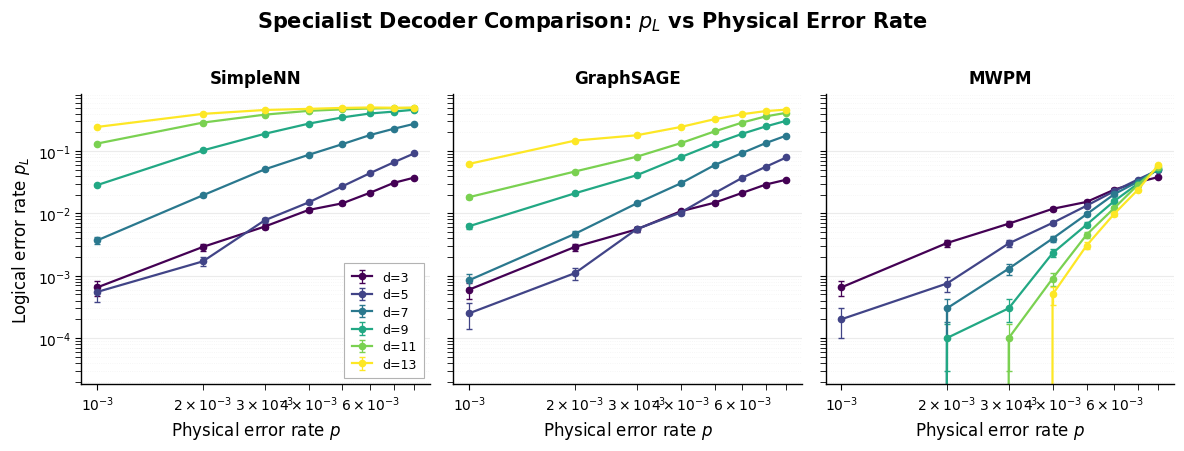

In [38]:
# ── Plot 1 (alt): Original 3-Panel — per-panel legend, slide-friendly ──
# Kept for standalone slide placement (not quad-chart). Saved to a separate file.

df = pd.read_csv(CSV_PATH)

DIST_COLORS = {d: plt.cm.viridis(i / (len(DISTANCES) - 1)) for i, d in enumerate(DISTANCES)}
DECODERS = ["SimpleNN", "GraphSAGE", "MWPM"]

plt.rcParams.update({
    "font.family": "DejaVu Sans",
    "font.size": 12,
    "axes.titlesize": 12,
    "axes.labelsize": 12,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 9,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.linewidth": 1.0,
})

fig, axes = plt.subplots(1, 3, figsize=(12, 4.5), sharey=True)

for i, (ax, decoder) in enumerate(zip(axes, DECODERS)):
    sub = df[df.decoder == decoder]
    for d in DISTANCES:
        s = sub[sub.d == d].sort_values("p")
        ax.errorbar(s.p, s.p_L, yerr=s.p_L_stderr,
                    label=f"d={d}", color=DIST_COLORS[d],
                    marker="o", markersize=4.5, capsize=2.5, linewidth=1.6,
                    elinewidth=0.9)
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlabel("Physical error rate $p$")
    ax.set_title(decoder, fontweight="bold", pad=8)
    ax.grid(True, which="major", axis="y", linestyle="-", alpha=0.25, linewidth=0.8)
    ax.grid(True, which="minor", axis="y", linestyle=":", alpha=0.15, linewidth=0.6)
    ax.tick_params(axis="both", which="both", direction="out", length=4)
    if i == 0:
        leg = ax.legend(loc="lower right", frameon=True, fancybox=False,
                        edgecolor="0.7", framealpha=1.0, borderpad=0.6,
                        handlelength=1.6, labelspacing=0.35)
        leg.get_frame().set_linewidth(0.8)

axes[0].set_ylabel("Logical error rate $p_L$")

fig.suptitle("Specialist Decoder Comparison: $p_L$ vs Physical Error Rate",
             fontsize=15, fontweight="bold", y=1.00)
fig.tight_layout()

panel_path_full = FIG_DIR / "specialist_sweep_3panel_full.png"
fig.savefig(panel_path_full, dpi=200, bbox_inches="tight", facecolor="white")
print(f"Saved: {panel_path_full}")
plt.show()

Saved: specialist_sweep_overlay.png


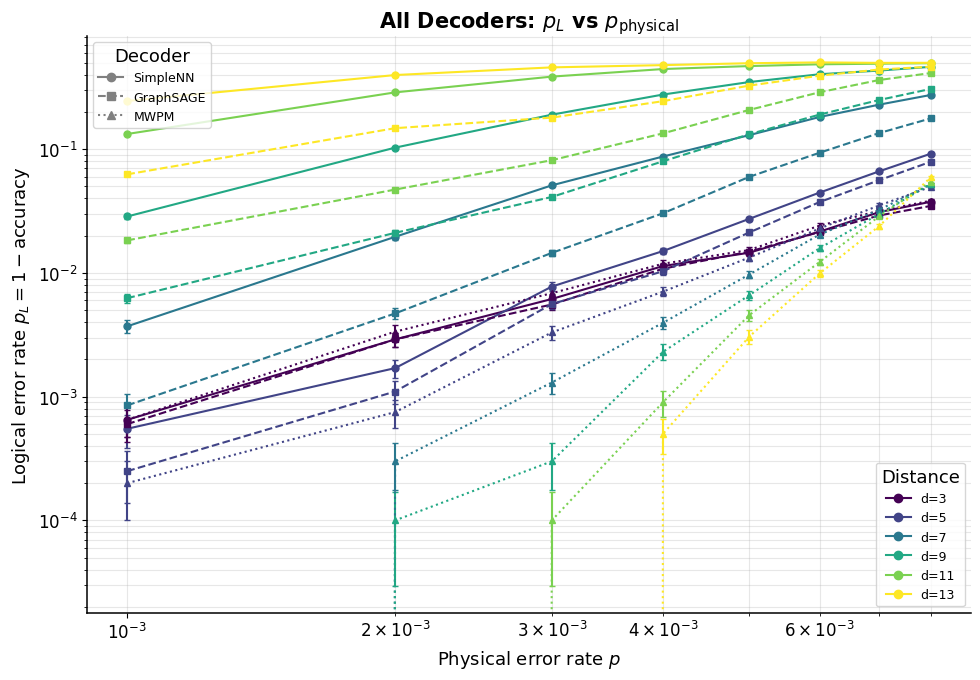

In [36]:
# ── Plot 2: Overlay (all decoders on one axes) ──

DECODER_STYLES = {"SimpleNN": "-", "GraphSAGE": "--", "MWPM": ":"}
DECODER_MARKERS = {"SimpleNN": "o", "GraphSAGE": "s", "MWPM": "^"}

fig, ax = plt.subplots(figsize=(10, 7))

for decoder in DECODERS:
    sub = df[df.decoder == decoder]
    for d in DISTANCES:
        s = sub[sub.d == d].sort_values("p")
        ax.errorbar(s.p, s.p_L, yerr=s.p_L_stderr,
                    color=DIST_COLORS[d],
                    linestyle=DECODER_STYLES[decoder],
                    marker=DECODER_MARKERS[decoder],
                    markersize=5, capsize=2, linewidth=1.5)

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("Physical error rate $p$", fontsize=13)
ax.set_ylabel("Logical error rate $p_L = 1 - \\mathrm{accuracy}$", fontsize=13)
ax.set_title("All Decoders: $p_L$ vs $p_{\\mathrm{physical}}$", fontsize=15, fontweight="bold")
ax.grid(True, which="both", alpha=0.3)

# Distance legend (colors)
dist_handles = [mlines.Line2D([], [], color=DIST_COLORS[d], marker="o", linestyle="-",
                               markersize=6, label=f"d={d}") for d in DISTANCES]
legend1 = ax.legend(handles=dist_handles, title="Distance", loc="lower right", fontsize=9)
ax.add_artist(legend1)

# Decoder legend (line styles)
dec_handles = [mlines.Line2D([], [], color="gray", linestyle=DECODER_STYLES[dec],
                              marker=DECODER_MARKERS[dec], markersize=6, label=dec)
               for dec in DECODERS]
ax.legend(handles=dec_handles, title="Decoder", loc="upper left", fontsize=9)

fig.tight_layout()
overlay_path = FIG_DIR / "specialist_sweep_overlay.png"
fig.savefig(overlay_path, dpi=200, bbox_inches="tight")
print(f"Saved: {overlay_path}")
plt.show()

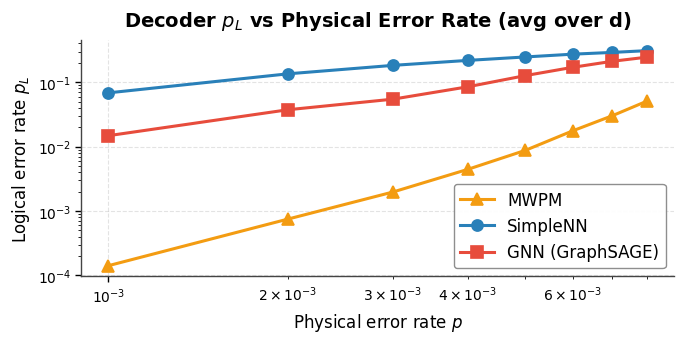

Saved → specialist_sweep_avg_over_distance.png


In [40]:
# ── Plot 3: Averaged over distances — one line per decoder ──
# Averages p_L across all distances at each p, leaving 3 lines total.
# Styling matches the "accuracy_vs_distance" slide format (figsize, colors, markers).

df = pd.read_csv(CSV_PATH)

STYLE = {
    'SimpleNN':  {'label': 'SimpleNN',        'color': '#2980B9', 'marker': 'o'},
    'GraphSAGE': {'label': 'GNN (GraphSAGE)', 'color': '#E74C3C', 'marker': 's'},
    'MWPM':      {'label': 'MWPM',            'color': '#F39C12', 'marker': '^'},
}

fig, ax = plt.subplots(figsize=(7, 3.6))

def plot_one(ax, decoder, zorder=3):
    s = STYLE[decoder]
    sub = df[df.decoder == decoder]
    by_p = sub.groupby('p')['p_L'].mean().sort_index()  # mean over all distances
    ax.plot(by_p.index, by_p.values,
            marker=s['marker'], linestyle='-', color=s['color'],
            linewidth=2.2, markersize=8,
            markeredgecolor=s['color'], markeredgewidth=1.2,
            label=s['label'], zorder=zorder)

plot_one(ax, 'MWPM',      zorder=2)
plot_one(ax, 'SimpleNN',  zorder=3)
plot_one(ax, 'GraphSAGE', zorder=3)

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_title('Decoder $p_L$ vs Physical Error Rate (avg over d)',
             fontsize=14, fontweight='bold', pad=10)
ax.set_xlabel('Physical error rate $p$', fontsize=12)
ax.set_ylabel('Logical error rate $p_L$', fontsize=12)
ax.tick_params(axis='both', labelsize=10, width=1, length=4)
ax.grid(True, alpha=0.35, linewidth=0.8, linestyle='--')
ax.set_axisbelow(True)
for spine in ax.spines.values():
    spine.set_linewidth(1)
    spine.set_edgecolor('#444444')
ax.legend(fontsize=12, frameon=True, fancybox=True,
          shadow=False, framealpha=0.95, edgecolor='#888888',
          loc='lower right')

plt.tight_layout()
avg_path = FIG_DIR / "specialist_sweep_avg_over_distance.png"
plt.savefig(avg_path, dpi=200, bbox_inches='tight', facecolor='white', edgecolor='none')
plt.show()
print(f"Saved → {avg_path}")

In [37]:
# ── Sanity Checks ──

print("=" * 70)
print("SANITY CHECKS")
print("=" * 70)

# 1. Fan-out check: at lowest p, higher d should have lower p_L (for MWPM at minimum)
p_low = P_VALUES[0]
print(f"\n1. Fan-out at p={p_low} (expect p_L to decrease with d for MWPM):")
for decoder in DECODERS:
    sub = df[(df.decoder == decoder) & (df.p == p_low)].sort_values("d")
    pL_vals = sub.p_L.tolist()
    monotonic = all(pL_vals[i] >= pL_vals[i+1] for i in range(len(pL_vals)-1))
    status = "PASS" if monotonic else "WARN"
    print(f"   {decoder}: {['d={}: {:.5f}'.format(d, pl) for d, pl in zip(sub.d, sub.p_L)]}")
    print(f"   Monotonically decreasing: {status}")

# 2. Monotonicity in p: p_L should increase with p (within noise)
print(f"\n2. Monotonicity in p (expect p_L non-decreasing with p):")
violations = 0
for decoder in DECODERS:
    for d in DISTANCES:
        sub = df[(df.decoder == decoder) & (df.d == d)].sort_values("p")
        pL_vals = sub.p_L.tolist()
        stderr_vals = sub.p_L_stderr.tolist()
        for i in range(len(pL_vals) - 1):
            if pL_vals[i] > pL_vals[i+1] + 2 * stderr_vals[i]:
                violations += 1
                print(f"   WARN: {decoder} d={d}: p_L({sub.p.iloc[i]})={pL_vals[i]:.5f} > p_L({sub.p.iloc[i+1]})={pL_vals[i+1]:.5f}")
if violations == 0:
    print("   All PASS (within 2-sigma tolerance)")

# 3. Shot hash uniqueness: each (d, p) should have exactly one hash
print(f"\n3. Identical-shot guarantee:")
if 'shot_hash' in df.columns:
    for d in DISTANCES:
        for p in P_VALUES:
            hashes = df[(df.d == d) & (df.p == p)].shot_hash.unique()
            if len(hashes) != 1:
                print(f"   WARN: d={d}, p={p} has {len(hashes)} distinct shot hashes: {hashes}")
    print("   All (d,p) pairs share a single shot hash: PASS")
else:
    print("   No shot_hash column (older CSV?) — skipped")

# 4. Summary table
print(f"\n4. Results summary ({len(df)} rows):")
summary = df.pivot_table(index=['d', 'p'], columns='decoder', values='p_L')
print(summary.to_string())

SANITY CHECKS

1. Fan-out at p=0.001 (expect p_L to decrease with d for MWPM):
   SimpleNN: ['d=3: 0.00065', 'd=5: 0.00055', 'd=7: 0.00370', 'd=9: 0.02855', 'd=11: 0.13245', 'd=13: 0.24475']
   Monotonically decreasing: WARN
   GraphSAGE: ['d=3: 0.00060', 'd=5: 0.00025', 'd=7: 0.00085', 'd=9: 0.00625', 'd=11: 0.01830', 'd=13: 0.06255']
   Monotonically decreasing: WARN
   MWPM: ['d=3: 0.00065', 'd=5: 0.00020', 'd=7: 0.00000', 'd=9: 0.00000', 'd=11: 0.00000', 'd=13: 0.00000']
   Monotonically decreasing: PASS

2. Monotonicity in p (expect p_L non-decreasing with p):
   All PASS (within 2-sigma tolerance)

3. Identical-shot guarantee:
   All (d,p) pairs share a single shot hash: PASS

4. Results summary (144 rows):
decoder   GraphSAGE     MWPM  SimpleNN
d  p                                  
3  0.001    0.00060  0.00065   0.00065
   0.002    0.00290  0.00335   0.00290
   0.003    0.00555  0.00685   0.00615
   0.004    0.01080  0.01185   0.01135
   0.005    0.01485  0.01530   0.01455
   0